# 92. Embeddingモデル STS ベンチマーク評価

## 目的
実験91で比較した軽量Embeddingモデルについて、意味的類似度（STS）ベンチマークで
Embeddingモデルとしての本来の性能を評価する。

## 評価ベンチマーク
| ベンチマーク | 言語 | ペア数(test) | スコア範囲 | 概要 |
|------------|------|-------------|-----------|------|
| JSTS | 日本語 | ~1,457 | 0-5 | 画像キャプションペアの意味的類似度 |
| JSICK | 日本語 | ~4,927 | 1-5 | SICK日本語版、構文理解の評価 |
| STS-B | 英語 | ~1,379 | 0-5 | ニュース・キャプション等の意味的類似度 |

## 評価指標
- Spearman相関（コサイン類似度 vs 人手スコア）
- Pearson相関

## 評価対象モデル（実験91と同一）
1. multilingual-e5-base (baseline)
2. EmbeddingGemma-300M
3. Qwen3-Embedding-0.6B
4. Qwen3-Embedding-8B
5. BGE-M3
6. PLaMo-Embedding-1B
7. Ruri-v3-310m

## 0. セットアップ

In [1]:
import numpy as np
import gc
import torch
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from datasets import load_dataset

DATA_DIR = Path("../data")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


## 1. STSデータセットの読み込み

In [2]:
# JSTS (Japanese STS) - JGLUEから直接ロード
import json, urllib.request, io

jsts_url = "https://raw.githubusercontent.com/yahoojapan/JGLUE/v1.1.0/datasets/jsts-v1.1/valid-v1.1.json"
with urllib.request.urlopen(jsts_url) as resp:
    jsts_raw = [json.loads(line) for line in resp.read().decode('utf-8').strip().split('\n')]

# Dataset風のdictに変換
jsts = {
    'sentence1': [d['sentence1'] for d in jsts_raw],
    'sentence2': [d['sentence2'] for d in jsts_raw],
    'label': [d['label'] for d in jsts_raw],
    'column_names': ['sentence1', 'sentence2', 'label'],
}
print(f"JSTS: {len(jsts['sentence1'])} pairs")
print(f"  columns: {jsts['column_names']}")
print(f"  score range: [{min(jsts['label'])}, {max(jsts['label'])}]")
print(f"  sample: s1={jsts['sentence1'][0][:60]}, s2={jsts['sentence2'][0][:60]}, label={jsts['label'][0]}")

JSTS: 1457 pairs
  columns: ['sentence1', 'sentence2', 'label']
  score range: [0.0, 5.0]
  sample: s1=レンガの建物の前を、乳母車を押した女性が歩いています。, s2=厩舎で馬と女性とが寄り添っています。, label=0.0


In [3]:
# JSICK (Japanese SICK) - GitHubから直接ロード
jsick_url = "https://raw.githubusercontent.com/verypluming/JSICK/b3034994192fae2f41b5937bcf69544e4282fc39/jsick/jsick.tsv"
with urllib.request.urlopen(jsick_url) as resp:
    jsick_df = pd.read_csv(io.StringIO(resp.read().decode('utf-8')), delimiter='\t')

# testスプリットのみ (JMTEBと同じ: data == "test")
jsick_test = jsick_df[jsick_df['data'] == 'test'].reset_index(drop=True)
jsick = {
    'sentence1': jsick_test['sentence_A_Ja'].tolist(),
    'sentence2': jsick_test['sentence_B_Ja'].tolist(),
    'label': jsick_test['relatedness_score_Ja'].tolist(),
    'column_names': ['sentence1', 'sentence2', 'label'],
}
print(f"JSICK: {len(jsick['sentence1'])} pairs")
print(f"  columns: {jsick['column_names']}")
print(f"  score range: [{min(jsick['label']):.2f}, {max(jsick['label']):.2f}]")
print(f"  sample: s1={jsick['sentence1'][0][:60]}, s2={jsick['sentence2'][0][:60]}, label={jsick['label'][0]}")

JSICK: 4927 pairs
  columns: ['sentence1', 'sentence2', 'label']
  score range: [1.00, 5.00]
  sample: s1=戸外で遊んでいる男の子は一人もおらず、微笑んでいる男性は一人もいない, s2=子供たちのグループが庭で遊んでいて、後ろの方には年を取った男性が立っている, label=2.3


In [4]:
# STS-B (English) - sentence-transformers/stsb はスクリプト不要
stsb_ds = load_dataset("sentence-transformers/stsb", split="test")
stsb = {
    'sentence1': stsb_ds['sentence1'],
    'sentence2': stsb_ds['sentence2'],
    'label': stsb_ds['score'],
    'column_names': ['sentence1', 'sentence2', 'label'],
}
print(f"STS-B: {len(stsb['sentence1'])} pairs")
print(f"  columns: {stsb['column_names']}")
print(f"  score range: [{min(stsb['label']):.2f}, {max(stsb['label']):.2f}]")
print(f"  sample: s1={stsb['sentence1'][0][:60]}, s2={stsb['sentence2'][0][:60]}, label={stsb['label'][0]}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/471k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/108k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

STS-B: 1379 pairs
  columns: ['sentence1', 'sentence2', 'label']
  score range: [0.00, 1.00]
  sample: s1=A girl is styling her hair., s2=A girl is brushing her hair., label=0.5


## 2. 評価関数

In [5]:
def compute_sts_metrics(embeddings1: np.ndarray, embeddings2: np.ndarray,
                        gold_scores: list[float]) -> dict:
    """コサイン類似度とゴールドスコアのSpearman/Pearson相関を計算"""
    # コサイン類似度（正規化済みならドット積）
    cos_sims = np.sum(embeddings1 * embeddings2, axis=1)
    gold = np.array(gold_scores)

    spearman, sp_pval = spearmanr(cos_sims, gold)
    pearson, pe_pval = pearsonr(cos_sims, gold)

    return {
        'spearman': float(spearman),
        'pearson': float(pearson),
        'sp_pval': float(sp_pval),
        'pe_pval': float(pe_pval),
    }


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

print("Evaluation functions ready.")

Evaluation functions ready.


## 3. STSデータの準備

各データセットから sentence1, sentence2, score を抽出する。
JMTEBのデータ構造に合わせてカラム名を確認・調整する。

In [6]:
# データは既にdict形式で統一済み（sentence1, sentence2, label）
sts_datasets = {
    'JSTS': {'sentences1': jsts['sentence1'], 'sentences2': jsts['sentence2'], 'scores': jsts['label']},
    'JSICK': {'sentences1': jsick['sentence1'], 'sentences2': jsick['sentence2'], 'scores': jsick['label']},
    'STS-B': {'sentences1': stsb['sentence1'], 'sentences2': stsb['sentence2'], 'scores': stsb['label']},
}

for name, data in sts_datasets.items():
    print(f"{name}: {len(data['sentences1'])} pairs, score range: [{min(data['scores']):.2f}, {max(data['scores']):.2f}]")

JSTS: 1457 pairs, score range: [0.00, 5.00]
JSICK: 4927 pairs, score range: [1.00, 5.00]
STS-B: 1379 pairs, score range: [0.00, 1.00]


## 4. モデル別STS評価

各モデルを順番にロード → STS文ペアをエンコード → 相関計算 → アンロード。
STSデータは小規模（最大~5000ペア）なので各モデル1分以内で完了する。

In [7]:
import time
from sentence_transformers import SentenceTransformer

# 評価結果格納用
all_sts_results = []


def evaluate_model_sts(model_key: str, model_name: str,
                       encode_fn, prefix_fn=None) -> list[dict]:
    """全STSデータセットでモデルを評価"""
    results = []
    for ds_name, ds_data in sts_datasets.items():
        s1 = ds_data['sentences1']
        s2 = ds_data['sentences2']
        scores = ds_data['scores']

        # プレフィックス適用
        if prefix_fn:
            s1 = [prefix_fn(s) for s in s1]
            s2 = [prefix_fn(s) for s in s2]

        # エンコード
        start = time.time()
        emb1 = encode_fn(s1)
        emb2 = encode_fn(s2)
        elapsed = time.time() - start

        # 評価
        metrics = compute_sts_metrics(emb1, emb2, scores)
        metrics['model'] = model_key
        metrics['dataset'] = ds_name
        metrics['time_sec'] = elapsed
        results.append(metrics)

        print(f"  {ds_name}: Spearman={metrics['spearman']:.4f}, "
              f"Pearson={metrics['pearson']:.4f} ({elapsed:.1f}s)")
    return results

print("Evaluation framework ready.")

Evaluation framework ready.


### 4.1 multilingual-e5-base (baseline)

In [8]:
print("Loading multilingual-e5-base...")
model = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")

def encode_e5(texts):
    return model.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)

results = evaluate_model_sts(
    'e5_base', 'multilingual-e5-base',
    encode_e5, prefix_fn=lambda s: f"query: {s}"
)
all_sts_results.extend(results)

del model; clear_gpu()
print("Done.")

Loading multilingual-e5-base...
  JSTS: Spearman=0.7965, Pearson=0.8427 (0.8s)
  JSICK: Spearman=0.8056, Pearson=0.8134 (1.7s)
  STS-B: Spearman=0.8564, Pearson=0.8379 (0.5s)
Done.


### 4.2 EmbeddingGemma-300M

In [9]:
print("Loading EmbeddingGemma-300M...")
model = SentenceTransformer("google/embeddinggemma-300m", device="cuda")

def encode_gemma(texts):
    return model.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)

results = evaluate_model_sts(
    'gemma_300m', 'EmbeddingGemma-300M',
    encode_gemma
)
all_sts_results.extend(results)

del model; clear_gpu()
print("Done.")

Loading EmbeddingGemma-300M...
  JSTS: Spearman=0.8382, Pearson=0.8773 (1.4s)
  JSICK: Spearman=0.8170, Pearson=0.8295 (4.6s)
  STS-B: Spearman=0.8487, Pearson=0.8447 (1.6s)
Done.


### 4.3 Qwen3-Embedding-0.6B

In [10]:
print("Loading Qwen3-Embedding-0.6B...")
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")

def encode_qwen06(texts):
    return model.encode(texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False)

results = evaluate_model_sts(
    'qwen3_06b', 'Qwen3-Embedding-0.6B',
    encode_qwen06
)
all_sts_results.extend(results)

del model; clear_gpu()
print("Done.")

Loading Qwen3-Embedding-0.6B...
  JSTS: Spearman=0.8068, Pearson=0.8537 (2.9s)
  JSICK: Spearman=0.8331, Pearson=0.8428 (9.4s)
  STS-B: Spearman=0.8460, Pearson=0.8426 (3.1s)
Done.


### 4.4 Qwen3-Embedding-8B

In [11]:
print("Loading Qwen3-Embedding-8B...")
try:
    model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device="cuda",
                                model_kwargs={"torch_dtype": torch.float16})

    def encode_qwen8b(texts):
        emb = model.encode(texts, batch_size=8, normalize_embeddings=True, show_progress_bar=False)
        return emb.astype(np.float32)

    results = evaluate_model_sts(
        'qwen3_8b', 'Qwen3-Embedding-8B',
        encode_qwen8b
    )
    all_sts_results.extend(results)

    del model; clear_gpu()
    print("Done.")
except Exception as e:
    print(f"ERROR: {e}")
    print("8Bモデルをスキップ")
    clear_gpu()

Loading Qwen3-Embedding-8B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  JSTS: Spearman=0.8371, Pearson=0.8788 (13.1s)
  JSICK: Spearman=0.8505, Pearson=0.8609 (43.7s)
  STS-B: Spearman=0.8851, Pearson=0.8726 (12.9s)
Done.


### 4.5 BGE-M3

In [12]:
print("Loading BGE-M3...")
model = SentenceTransformer("BAAI/bge-m3", device="cuda")

def encode_bge(texts):
    return model.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)

results = evaluate_model_sts(
    'bge_m3', 'BGE-M3',
    encode_bge
)
all_sts_results.extend(results)

del model; clear_gpu()
print("Done.")

Loading BGE-M3...
  JSTS: Spearman=0.8023, Pearson=0.8467 (1.3s)
  JSICK: Spearman=0.7983, Pearson=0.8167 (4.0s)
  STS-B: Spearman=0.8485, Pearson=0.8371 (1.4s)
Done.


### 4.6 PLaMo-Embedding-1B

In [13]:
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F

print("Loading PLaMo-Embedding-1B...")
tokenizer = AutoTokenizer.from_pretrained("pfnet/plamo-embedding-1b", trust_remote_code=True)
plamo_model = AutoModel.from_pretrained("pfnet/plamo-embedding-1b", trust_remote_code=True)
plamo_model = plamo_model.to("cuda")
plamo_model.eval()

def encode_plamo(texts):
    all_embs = []
    batch_size = 32
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        with torch.inference_mode():
            embs = plamo_model.encode_query(batch, tokenizer)
            embs = F.normalize(embs, p=2, dim=1)
            all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

results = evaluate_model_sts(
    'plamo_1b', 'PLaMo-Embedding-1B',
    encode_plamo
)
all_sts_results.extend(results)

del plamo_model, tokenizer; clear_gpu()
print("Done.")

Loading PLaMo-Embedding-1B...
  JSTS: Spearman=0.8491, Pearson=0.8850 (7.9s)
  JSICK: Spearman=0.8131, Pearson=0.8200 (24.3s)
  STS-B: Spearman=0.8311, Pearson=0.8332 (6.8s)
Done.


### 4.7 Ruri-v3-310m

In [14]:
print("Loading Ruri-v3-310m...")
model = SentenceTransformer("cl-nagoya/ruri-v3-310m", device="cuda")

def encode_ruri(texts):
    return model.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=False)

results = evaluate_model_sts(
    'ruri_v3', 'Ruri-v3-310m',
    encode_ruri, prefix_fn=lambda s: f"検索クエリ: {s}"
)
all_sts_results.extend(results)

del model; clear_gpu()
print("Done.")

Loading Ruri-v3-310m...
  JSTS: Spearman=0.8305, Pearson=0.8784 (1.1s)
  JSICK: Spearman=0.8003, Pearson=0.8216 (3.3s)
  STS-B: Spearman=0.8367, Pearson=0.8427 (1.5s)
Done.


## 5. 結果比較

In [15]:
df_results = pd.DataFrame(all_sts_results)

# データセット別にSpearman相関を表示
print("="*80)
print("STS Benchmark Results: Spearman Correlation")
print("="*80)

pivot_sp = df_results.pivot(index='model', columns='dataset', values='spearman')
# モデル順を指定
model_order = ['e5_base', 'gemma_300m', 'qwen3_06b', 'qwen3_8b', 'bge_m3', 'plamo_1b', 'ruri_v3']
pivot_sp = pivot_sp.reindex([m for m in model_order if m in pivot_sp.index])
pivot_sp['AVG'] = pivot_sp.mean(axis=1)
print(pivot_sp.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n{'='*80}")
print("STS Benchmark Results: Pearson Correlation")
print("="*80)

pivot_pe = df_results.pivot(index='model', columns='dataset', values='pearson')
pivot_pe = pivot_pe.reindex([m for m in model_order if m in pivot_pe.index])
pivot_pe['AVG'] = pivot_pe.mean(axis=1)
print(pivot_pe.to_string(float_format=lambda x: f"{x:.4f}"))

STS Benchmark Results: Spearman Correlation
dataset     JSICK   JSTS  STS-B    AVG
model                                 
e5_base    0.8056 0.7965 0.8564 0.8195
gemma_300m 0.8170 0.8382 0.8487 0.8346
qwen3_06b  0.8331 0.8068 0.8460 0.8286
qwen3_8b   0.8505 0.8371 0.8851 0.8576
bge_m3     0.7983 0.8023 0.8485 0.8164
plamo_1b   0.8131 0.8491 0.8311 0.8311
ruri_v3    0.8003 0.8305 0.8367 0.8225

STS Benchmark Results: Pearson Correlation
dataset     JSICK   JSTS  STS-B    AVG
model                                 
e5_base    0.8134 0.8427 0.8379 0.8313
gemma_300m 0.8295 0.8773 0.8447 0.8505
qwen3_06b  0.8428 0.8537 0.8426 0.8463
qwen3_8b   0.8609 0.8788 0.8726 0.8707
bge_m3     0.8167 0.8467 0.8371 0.8335
plamo_1b   0.8200 0.8850 0.8332 0.8461
ruri_v3    0.8216 0.8784 0.8427 0.8476


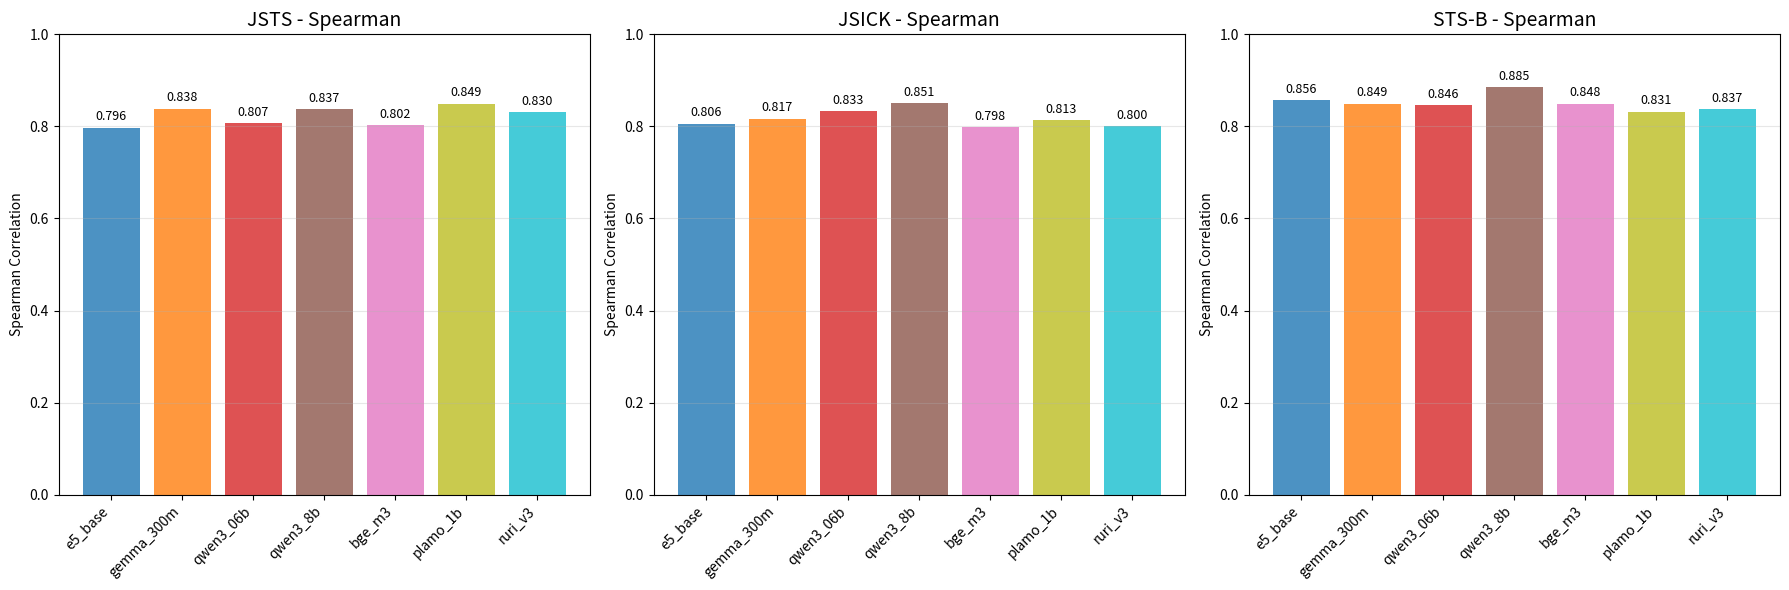

Saved: data/92_sts_benchmark_spearman.png


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets_list = ['JSTS', 'JSICK', 'STS-B']
colors = plt.cm.tab10(np.linspace(0, 1, len(model_order)))

for ax_idx, ds_name in enumerate(datasets_list):
    ds_data = df_results[df_results['dataset'] == ds_name]
    # モデル順に並べ替え
    ds_data = ds_data.set_index('model').reindex(
        [m for m in model_order if m in ds_data['model'].values]
    ).reset_index()

    models = ds_data['model'].tolist()
    x = np.arange(len(models))

    bars = axes[ax_idx].bar(x, ds_data['spearman'], alpha=0.8,
                           color=[colors[model_order.index(m)] for m in models])
    axes[ax_idx].set_title(f'{ds_name} - Spearman', fontsize=14)
    axes[ax_idx].set_ylabel('Spearman Correlation')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(models, rotation=45, ha='right')
    axes[ax_idx].grid(axis='y', alpha=0.3)
    axes[ax_idx].set_ylim(0, 1.0)

    # 値をバーの上に表示
    for bar, val in zip(bars, ds_data['spearman']):
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / "92_sts_benchmark_spearman.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/92_sts_benchmark_spearman.png")

In [17]:
# 実験91のITQ-LSH品質との対比
# 実験91の結果をnpyから再計算
import sys
sys.path.insert(0, '../src')
from itq_lsh import ITQLSH

itq_spearman_ja = {}
itq_spearman_en = {}

for key in model_order:
    ja_path = DATA_DIR / f"10k_{key}_ja_embeddings.npy"
    en_path = DATA_DIR / f"10k_{key}_en_embeddings.npy"

    for path, result_dict, lang in [(ja_path, itq_spearman_ja, 'JA'),
                                    (en_path, itq_spearman_en, 'EN')]:
        if not path.exists():
            continue
        emb = np.load(path).astype(np.float32)
        n_bits = min(128, emb.shape[1])
        itq = ITQLSH(n_bits=n_bits, n_iterations=50, seed=42)
        itq.fit(emb)
        hashes = itq.transform(emb)

        rng = np.random.default_rng(42)
        n = len(emb)
        idx1 = rng.choice(n, 10000, replace=True)
        idx2 = rng.choice(n, 10000, replace=True)
        mask = idx1 != idx2
        idx1, idx2 = idx1[mask], idx2[mask]

        cos_sims = np.sum(emb[idx1] * emb[idx2], axis=1)
        ham_dists = np.sum(hashes[idx1] != hashes[idx2], axis=1)
        corr, _ = spearmanr(ham_dists, cos_sims)
        result_dict[key] = abs(corr)

print("ITQ-LSH Spearman (from Exp91) recomputed.")

ITQ学習開始: samples=9990, dim=768, bits=128
  Centering完了: mean_norm=0.8749
  PCA完了: explained_variance=68.22%
  ITQ iteration 10: quantization_error=0.9428
  ITQ iteration 20: quantization_error=0.9424
  ITQ iteration 30: quantization_error=0.9423
  ITQ iteration 40: quantization_error=0.9422
  ITQ iteration 50: quantization_error=0.9421
ITQ学習完了
ITQ学習開始: samples=10000, dim=768, bits=128
  Centering完了: mean_norm=0.8404
  PCA完了: explained_variance=61.78%
  ITQ iteration 10: quantization_error=0.9399
  ITQ iteration 20: quantization_error=0.9396
  ITQ iteration 30: quantization_error=0.9394
  ITQ iteration 40: quantization_error=0.9393
  ITQ iteration 50: quantization_error=0.9393
ITQ学習完了
ITQ学習開始: samples=9990, dim=768, bits=128
  Centering完了: mean_norm=0.3483
  PCA完了: explained_variance=63.29%
  ITQ iteration 10: quantization_error=0.8949
  ITQ iteration 20: quantization_error=0.8942
  ITQ iteration 30: quantization_error=0.8939
  ITQ iteration 40: quantization_error=0.8937
  ITQ iteration

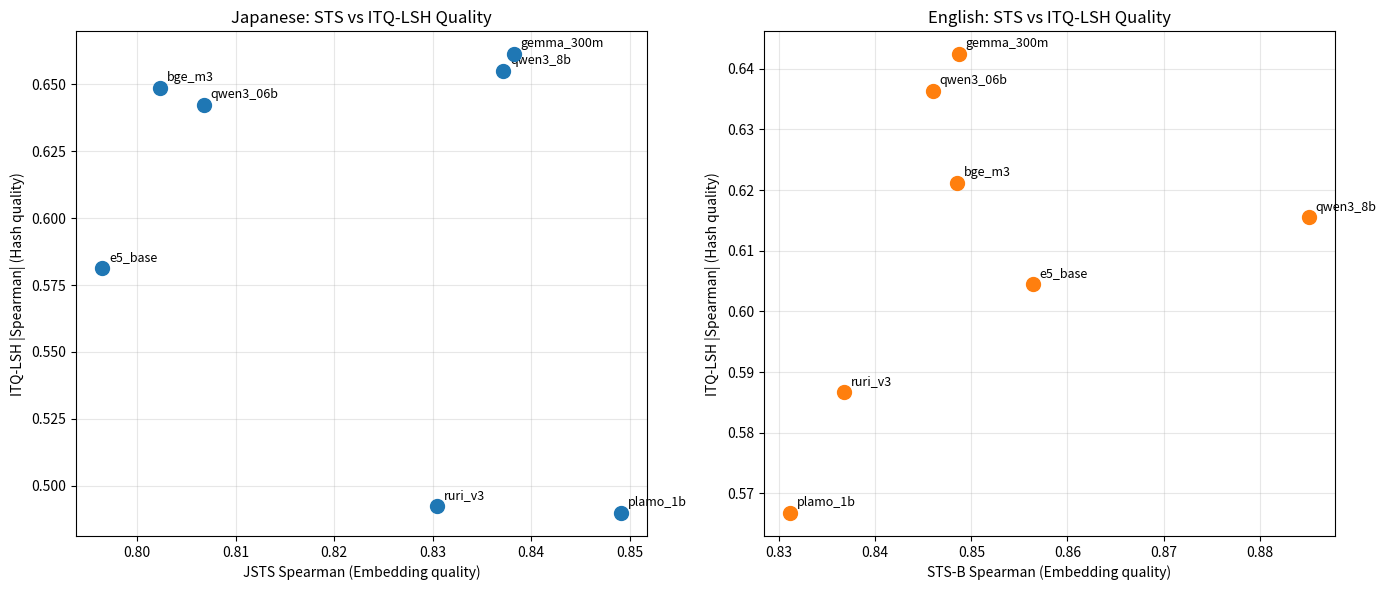

Saved: data/92_sts_vs_itq_scatter.png


In [18]:
# STS性能 vs ITQ-LSHハッシュ品質の散布図
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# JSTS Spearman vs ITQ-LSH Spearman (JA)
jsts_results = df_results[df_results['dataset'] == 'JSTS'].set_index('model')
models_with_both = [m for m in model_order
                    if m in jsts_results.index and m in itq_spearman_ja]

sts_vals = [jsts_results.loc[m, 'spearman'] for m in models_with_both]
itq_vals = [itq_spearman_ja[m] for m in models_with_both]

axes[0].scatter(sts_vals, itq_vals, s=100, zorder=5)
for i, m in enumerate(models_with_both):
    axes[0].annotate(m, (sts_vals[i], itq_vals[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('JSTS Spearman (Embedding quality)')
axes[0].set_ylabel('ITQ-LSH |Spearman| (Hash quality)')
axes[0].set_title('Japanese: STS vs ITQ-LSH Quality')
axes[0].grid(alpha=0.3)

# STS-B Spearman vs ITQ-LSH Spearman (EN)
stsb_results = df_results[df_results['dataset'] == 'STS-B'].set_index('model')
models_with_both_en = [m for m in model_order
                       if m in stsb_results.index and m in itq_spearman_en]

sts_vals_en = [stsb_results.loc[m, 'spearman'] for m in models_with_both_en]
itq_vals_en = [itq_spearman_en[m] for m in models_with_both_en]

axes[1].scatter(sts_vals_en, itq_vals_en, s=100, zorder=5, color='tab:orange')
for i, m in enumerate(models_with_both_en):
    axes[1].annotate(m, (sts_vals_en[i], itq_vals_en[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[1].set_xlabel('STS-B Spearman (Embedding quality)')
axes[1].set_ylabel('ITQ-LSH |Spearman| (Hash quality)')
axes[1].set_title('English: STS vs ITQ-LSH Quality')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "92_sts_vs_itq_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/92_sts_vs_itq_scatter.png")

## 6. 総合サマリー

In [19]:
print("="*90)
print("実験92: STS ベンチマーク評価 - 総合サマリー")
print("="*90)

# 総合テーブル
summary = []
for m in model_order:
    row = {'model': m}

    # STS results
    for ds_name in ['JSTS', 'JSICK', 'STS-B']:
        ds_data = df_results[(df_results['model'] == m) & (df_results['dataset'] == ds_name)]
        if len(ds_data) > 0:
            row[f'{ds_name}_sp'] = ds_data.iloc[0]['spearman']

    # ITQ-LSH results
    if m in itq_spearman_ja:
        row['ITQ_JA'] = itq_spearman_ja[m]
    if m in itq_spearman_en:
        row['ITQ_EN'] = itq_spearman_en[m]

    # STS average
    sts_cols = [v for k, v in row.items() if k.endswith('_sp')]
    if sts_cols:
        row['STS_AVG'] = np.mean(sts_cols)

    summary.append(row)

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "="*90)
print("STS Spearman: Embeddingモデルの意味的類似度捕捉能力")
print("ITQ |Spearman|: ITQ-LSHハッシュとコサイン類似度の相関（高いほど良い）")
print("="*90)

実験92: STS ベンチマーク評価 - 総合サマリー
     model  JSTS_sp  JSICK_sp  STS-B_sp  ITQ_JA  ITQ_EN  STS_AVG
   e5_base   0.7965    0.8056    0.8564  0.5814  0.6045   0.8195
gemma_300m   0.8382    0.8170    0.8487  0.6612  0.6424   0.8346
 qwen3_06b   0.8068    0.8331    0.8460  0.6423  0.6363   0.8286
  qwen3_8b   0.8371    0.8505    0.8851  0.6548  0.6155   0.8576
    bge_m3   0.8023    0.7983    0.8485  0.6485  0.6211   0.8164
  plamo_1b   0.8491    0.8131    0.8311  0.4899  0.5668   0.8311
   ruri_v3   0.8305    0.8003    0.8367  0.4923  0.5867   0.8225

STS Spearman: Embeddingモデルの意味的類似度捕捉能力
ITQ |Spearman|: ITQ-LSHハッシュとコサイン類似度の相関（高いほど良い）


## 7. 最終評価と考察

### STS Spearman 総合ランキング

| 順位 | モデル | JSTS (JA) | JSICK (JA) | STS-B (EN) | AVG | 備考 |
|------|--------|-----------|------------|------------|-----|------|
| 1 | **Qwen3-8B** | 0.837 | **0.851** | **0.885** | **0.858** | 全指標で最高水準 |
| 2 | EmbeddingGemma-300M | **0.838** | 0.817 | 0.849 | 0.835 | 308Mで2位は驚異的 |
| 3 | PLaMo-1B | 0.849 | 0.813 | 0.831 | 0.831 | JSTSでは最高スコア |
| 4 | Qwen3-0.6B | 0.807 | 0.833 | 0.846 | 0.829 | JSICKで強い |
| 5 | Ruri-v3-310m | 0.831 | 0.800 | 0.837 | 0.823 | 日本語特化だがSTS-Bも健闘 |
| 6 | **e5-base (BL)** | 0.797 | 0.806 | 0.856 | 0.820 | ベースライン |
| 7 | BGE-M3 | 0.802 | 0.798 | 0.849 | 0.816 | STS性能は最下位 |

### STS性能 vs ITQ-LSH品質の対比

| モデル | STS AVG | STS順位 | ITQ JA | ITQ EN | ITQ順位 | 乖離 |
|--------|---------|---------|--------|--------|---------|------|
| Qwen3-8B | 0.858 | 1 | 0.655 | 0.616 | 2 | 小 |
| Gemma-300M | 0.835 | 2 | **0.661** | **0.642** | **1** | 小 |
| PLaMo-1B | 0.831 | 3 | 0.490 | 0.567 | **7** | **大** |
| Qwen3-0.6B | 0.829 | 4 | 0.642 | 0.636 | 4 | 小 |
| Ruri-v3 | 0.823 | 5 | 0.492 | 0.587 | 6 | 大 |
| e5-base | 0.820 | 6 | 0.581 | 0.605 | 5 | 小 |
| BGE-M3 | 0.816 | 7 | 0.649 | 0.621 | 3 | **大（逆転）** |

### 考察

#### 1. STS性能とITQ-LSH品質は一致しない
最も重要な発見は、**STS性能が高いモデルが必ずしもITQ-LSHと相性が良いわけではない**こと。

- **PLaMo-1B**: STS 3位（0.831）だがITQ最下位（0.490）。2048次元→128bitへの圧縮で情報が大きく失われる。
- **BGE-M3**: STS最下位（0.816）だがITQ 3位（0.649）。等方的な空間構造がハッシュ化に適している。
- **Ruri-v3**: STS 5位だがITQ 6位。cos_mean=0.71と異方性が強く、バイナリ圧縮との相性が悪い。

この乖離の主因は**等方性**（実験91のcos_mean）にある。cos_meanが低いモデル（Gemma: 0.12, Qwen: 0.27）はSTS・ITQ両方で高性能だが、cos_meanが高いモデル（PLaMo: 0.40, Ruri: 0.71, E5: 0.77）はITQ品質が低下する。

#### 2. STS性能の全体水準
全モデルがSpearman 0.80-0.86の範囲に収まっており、**差は比較的小さい**（最大4pp）。一方、ITQ-LSH品質は0.49-0.66と**差が大きい**（最大17pp）。つまり、Embeddingモデルとしての基本性能はどれも十分だが、ITQ-LSHパイプラインでの実用性には大きな差がある。

#### 3. Qwen3-8Bの圧倒的品質
Qwen3-8Bは全STS指標で最高スコアかつITQ品質も2位と、品質面では文句なし。ただし推論速度がJA: 20 docs/sec（実験91）と極めて遅く、実用上はバッチ前処理限定。

#### 4. EmbeddingGemma-300Mの総合力
308Mパラメータで STS 2位・ITQ 1位と、**品質と圧縮効率の両立**において最も優れたモデル。実験91の等方性分析（cos_mean=0.12）とも整合する。ITQ-LSHパイプラインのデフォルトモデルとして最有力候補。

#### 5. 日本語評価の特徴
- **JSTS**: PLaMo-1B（0.849）とGemma（0.838）が強い。画像キャプション由来の短文評価で、日本語特化モデルが有利。
- **JSICK**: Qwen3-8B（0.851）とQwen3-0.6B（0.833）が強い。構文理解タスクでLLMベースモデルの強みが出る。
- Ruri-v3は日本語特化だが、JSICK（0.800）ではe5-base（0.806）に劣る。単純な意味類似よりも構文理解でやや弱い可能性。

### 結論: ITQ-LSHパイプラインに最適なモデル選択

| 優先度 | モデル | 理由 |
|--------|--------|------|
| **第1推奨** | **EmbeddingGemma-300M** | STS 2位 + ITQ 1位。軽量(308M)で等方的。品質と効率の最良バランス |
| 第2推奨 | Qwen3-Embedding-0.6B | STS 4位 + ITQ 4位。安定した性能。Gemmaより遅いがLLMベースの汎用性 |
| 品質最優先 | Qwen3-Embedding-8B | STS 1位 + ITQ 2位。速度を犠牲にすれば最高品質 |
| 非推奨 | PLaMo-1B, Ruri-v3 | STS性能は良いがITQ-LSHとの相性が悪い（異方性・高次元） |

**STS性能だけでモデルを選ぶと、ITQ-LSHパイプラインでは最適解にならない。**
等方性（cos_mean）とITQ Spearmanを併せて評価することが重要である。